In [65]:
import os
print(os.getcwd())

/home/egork/Coding/hrt-datathon/yehor


In [150]:
import pandas as pd

bars_df = pd.read_parquet("../data/bars_seen_train.parquet")
bars_unseen_df = pd.read_parquet("../data/bars_unseen_train.parquet")

headlines_df = pd.read_parquet("../data/headlines_seen_train.parquet")
print(bars_unseen_df.columns)
print(bars_unseen_df.head())
print(headlines_df.columns)
print(headlines_df.head())

Index(['bar_ix', 'session', 'open', 'high', 'low', 'close'], dtype='object')
                    bar_ix  session    open    high     low   close
96537893805296          50        0  1.0318  1.0375  1.0318  1.0367
130065551606496         50        1  1.0283  1.0297  1.0261  1.0282
96537893805296          50        2  1.0204  1.0217  1.0179  1.0202
96537960999696          50        3  1.0117  1.0129  1.0112  1.0126
749286384176075256      50        4  1.0281  1.0296  1.0263  1.0274
Index(['session', 'headline', 'bar_ix'], dtype='object')
                 session                                           headline  \
130065551606448        0  Relvos Biosciences opens new office in Southea...   
96537949420272         0  Orevex Renewables secures $500M contract with ...   
96537947165984         0  Relvos Biosciences names new head of precision...   
96537949420272         0  Calvis Sciences secures $650M contract with a ...   
49156                  0  Yorvov Pharmaceuticals secures $180M 

In [136]:
pharma_cluster = [
"Calvis Sciences",
"Calvos Genomics",
"Frelis Genomics",
"Grevel Diagnostics",
"Grevon Biotech",
"Jorvix Diagnostics",
"Krevum Pharmaceuticals",
"Myrnon Therapeutics",
"Nerval Biopharma",
"Relvos Biosciences",
"Wyrnik Sciences",
"Xelvol Biotech",
"Yorvov Pharmaceuticals",
"Zelvix Therapeutics",
"Zelvon Biosciences",
"Zrovum Biopharma"]

energy_cluster = [
"Jorvis Fuels",
"Kelvik Power",
"Kelvos Resources",
"Nerven Grid",
"Nolvol Resources",
"Orevex Renewables",
"Orevov Solutions",
"Plevep Power",
"Plevik Energy",
"Relvon Fuels",
"Strynal Industries",
"Ulvon Renewables",
"Urvel Grid",
"Wyrnor Solutions",
"Zelval Energy",
"Zrovex Industries"]

commerce_cluster = [
"Arnik Commerce",
"Arnos Marketplace",
"Crevol Retail",
"Frelex Outlets",
"Halvav Brands",
"Holtar Stores",
"Ixenis Outlets",
"Jorval Trading",
"Joval Brands",
"Nolvav Commerce",
"Orevar Marketplace",
"Pleven Trading",
"Talvyn Goods",
"Varvov Retail",
"Xovep Stores",
"Xovol Goods"]

money_cluster = [
"Creven Securities",
"Ervan Capital",
"Halven Investments",
"Halvix Holdings",
"Holtum Asset",
"Ilval Financial",
"Jorvyl Securities",
"Jovik Asset",
"Krevan Investments",
"Plevum Partners",
"Plevyl Advisors",
"Talvix Holdings",
"Wrelal Financial",
"Yorval Partners",
"Zelvel Capital",
"Zrovov Advisors"]

hardware_cluster = [
"Brevep Systems",
"Brevon Microchips",
"Crevex Labs",
"Dralol Computing",
"Frelol Software",
"Halvax Networks",
"Ixenix Technologies",
"Jovor Networks",
"Myrnep Technologies",
"Nolvis Devices",
"Prynis Systems",
"Relvan Software",
"Talvep Computing",
"Ulvyn Microchips",
"Volval Devices",
"Yorven Labs"
]

clusters = [pharma_cluster, energy_cluster, commerce_cluster, money_cluster, hardware_cluster]

In [137]:
df = headlines_df.copy()
print(df.columns)

clusters_sessions = {
    0 : set(),
    1 : set(),
    2 : set(),
    3 : set(),
    4 : set(),
}

for row in df.itertuples(index=False):
    # print(row)
    headline = row.headline
    session = int(row.session)

    for idx, cluster in enumerate(clusters):
        for company in cluster:
            if company in headline:
                clusters_sessions[idx].add(session)

print(clusters_sessions[0])
print(clusters_sessions[1])

Index(['session', 'headline', 'bar_ix'], dtype='object')
{0, 10, 11, 14, 17, 21, 27, 29, 33, 35, 37, 39, 41, 44, 47, 51, 52, 56, 57, 58, 59, 61, 64, 66, 68, 70, 71, 72, 79, 82, 85, 89, 91, 102, 105, 106, 111, 116, 118, 120, 124, 125, 129, 132, 140, 146, 151, 152, 157, 161, 165, 166, 169, 170, 172, 173, 177, 178, 181, 186, 190, 191, 195, 199, 202, 203, 205, 209, 211, 213, 216, 220, 222, 227, 229, 231, 234, 235, 236, 238, 239, 249, 251, 253, 258, 262, 263, 264, 268, 269, 272, 275, 279, 282, 286, 289, 292, 293, 296, 307, 314, 315, 317, 319, 320, 321, 322, 327, 328, 332, 333, 343, 347, 348, 351, 353, 354, 355, 358, 359, 362, 365, 369, 371, 376, 380, 383, 385, 386, 387, 388, 391, 395, 396, 397, 401, 406, 407, 410, 411, 415, 416, 417, 420, 421, 426, 427, 429, 430, 431, 432, 433, 435, 436, 437, 440, 444, 445, 448, 451, 455, 458, 461, 464, 466, 467, 468, 469, 471, 472, 475, 476, 477, 478, 479, 481, 482, 483, 487, 489, 492, 494, 500, 501, 503, 505, 510, 513, 514, 516, 524, 525, 526, 529, 534, 5

In [140]:
from collections import defaultdict

session_to_clusters = defaultdict(set)

for cluster_id, sessions in clusters_sessions.items():
    for s in sessions:
        session_to_clusters[s].add(cluster_id)

unique_to_one_cluster = {
    session: list(cluster_ids)[0]
    for session, cluster_ids in session_to_clusters.items()
    if len(cluster_ids) == 1
}

appear_in_two_clusters = {
    session: list(cluster_ids)[0]
    for session, cluster_ids in session_to_clusters.items()
    if len(cluster_ids) == 2
}

appear_in_three_clusters = {
    session: list(cluster_ids)[0]
    for session, cluster_ids in session_to_clusters.items()
    if len(cluster_ids) >= 3
}

print("Sessions in exactly one cluster:", len(unique_to_one_cluster))
print("Sessions in exactly two cluster:", len(appear_in_two_clusters))
print("Sessions in exactly three cluster:", len(appear_in_three_clusters))

Sessions in exactly one cluster: 240
Sessions in exactly two cluster: 760
Sessions in exactly three cluster: 0


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


def plot_session_with_news(
    bars_df,
    headlines_df,
    session_n,
    price_col="close",
    figsize=(14, 6),
    show_headlines=True,
    rotate_labels=90,
):
    """
    Plot price movement for a given session with vertical lines for headlines.

    Parameters
    ----------
    bars_df : pd.DataFrame
        Must contain columns:
        ['session', 'bar_ix', 'open', 'high', 'low', 'close']

    headlines_df : pd.DataFrame
        Must contain columns:
        ['session', 'headline', 'bar_ix']

    session_n : int
        Session number to plot.

    price_col : str
        Which price column to plot ('open', 'high', 'low', 'close').

    figsize : tuple
        Figure size.

    show_headlines : bool
        If True, annotate headlines on chart.

    rotate_labels : int
        Rotation angle for headline labels.
    """

    # Filter data
    bars = bars_df[bars_df["session"] == session_n].copy()
    news = headlines_df[headlines_df["session"] == session_n].copy()

    if bars.empty:
        print(f"No bars found for session {session_n}")
        return

    # Sort bars
    bars = bars.sort_values("bar_ix")
    news = news.sort_values("bar_ix")

    fig, ax = plt.subplots(figsize=figsize)

    # Plot price line
    ax.plot(
        bars["bar_ix"],
        bars[price_col],
        lw=2,
        label=f"{price_col.title()} Price"
    )

    # Vertical lines for headlines
    for _, row in news.iterrows():
        x = row["bar_ix"]

        ax.axvline(
            x=x,
            linestyle="--",
            alpha=0.6,
            linewidth=1
        )

        if show_headlines:
            ax.text(
                x,
                bars[price_col].max(),
                row["headline"],
                rotation=rotate_labels,
                va="top",
                ha="right",
                fontsize=8,
                alpha=0.8
            )

    ax.set_title(f"Session {session_n}: Price Movement + Headlines")
    ax.set_xlabel("bar_ix")
    ax.set_ylabel(price_col)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

In [144]:
headlines_to_sessions = {}

for row in df.itertuples(index=False):
    headline = row.headline
    session = int(row.session)
    if headline not in headlines_to_sessions:
        headlines_to_sessions[headline] = set()
    headlines_to_sessions[headline].add(session)

headlines_in_multiple_sessions = []

count = 10
for key, item in headlines_to_sessions.items():
    if count == 0:
        break
    if len(item) > 3:
        count -= 1
        print(key)
        print(sorted(item))
        print("=" * 30)
        headlines_in_multiple_sessions.append(sorted(item))
# a = sorted(headlines_in_multiple_sessions)

# for e in a:
#     print(e)

Frelol Software misses quarterly revenue estimates by 18%
[108, 415, 813, 892, 932]
Dralol Computing completes planned facility upgrade in Latin America
[134, 185, 194, 330]
Orevar Marketplace reports record quarterly revenue, up 5% year-over-year
[278, 341, 447, 703]


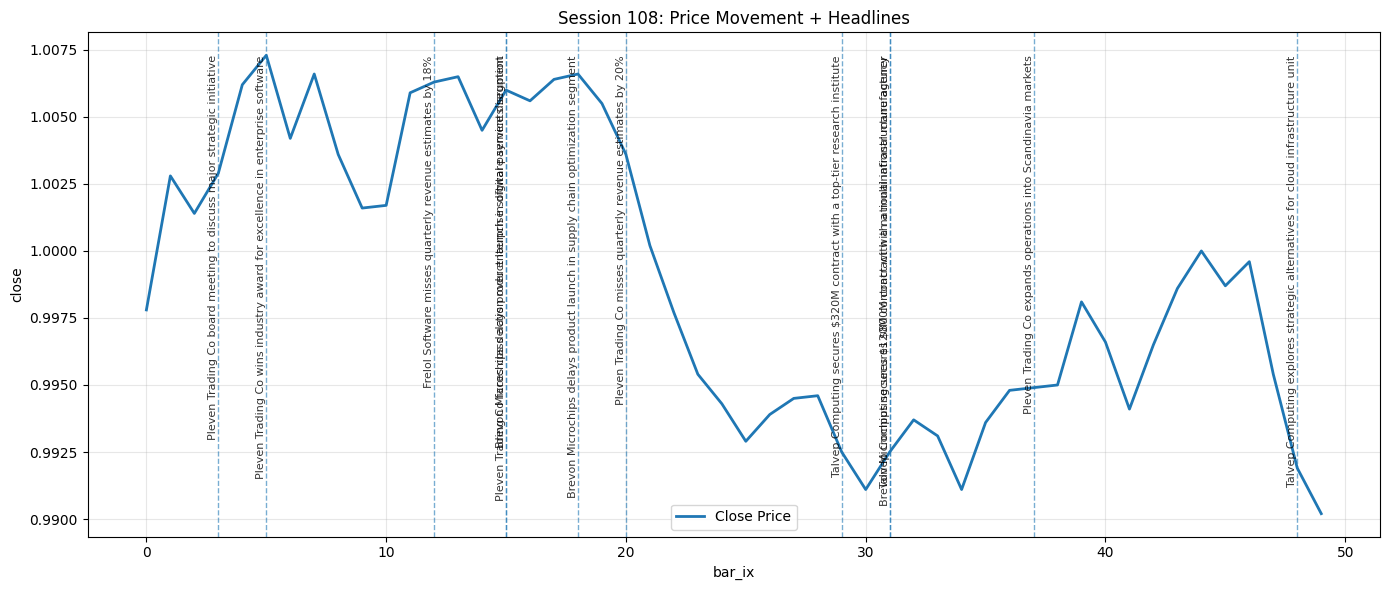

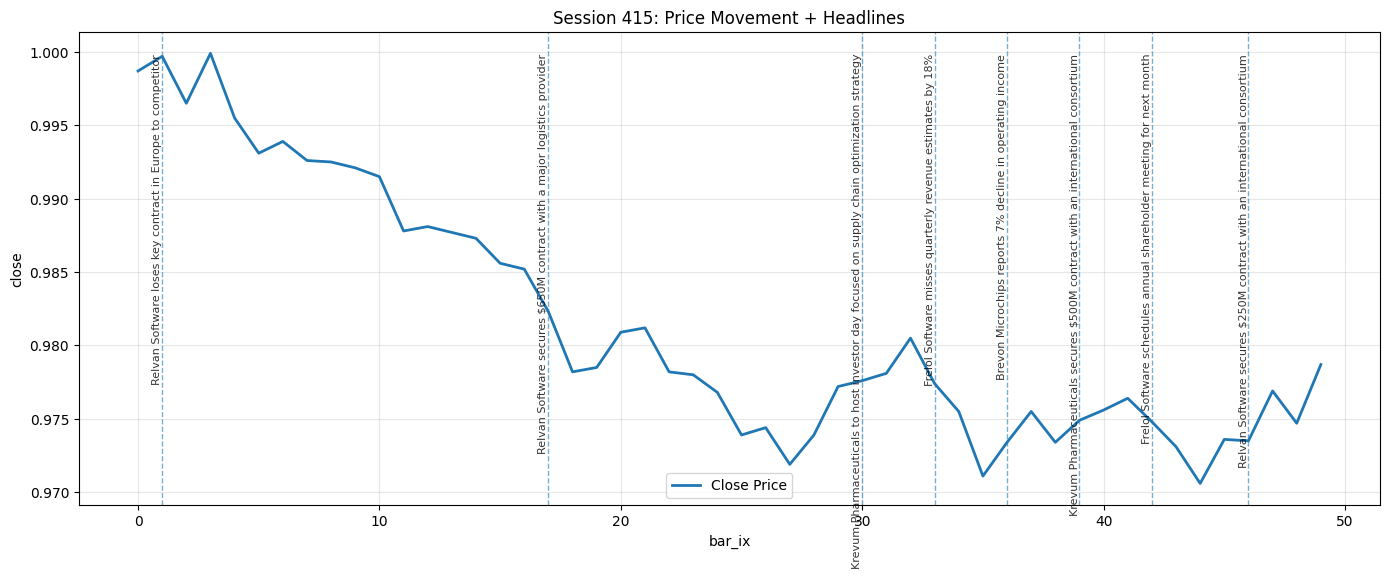

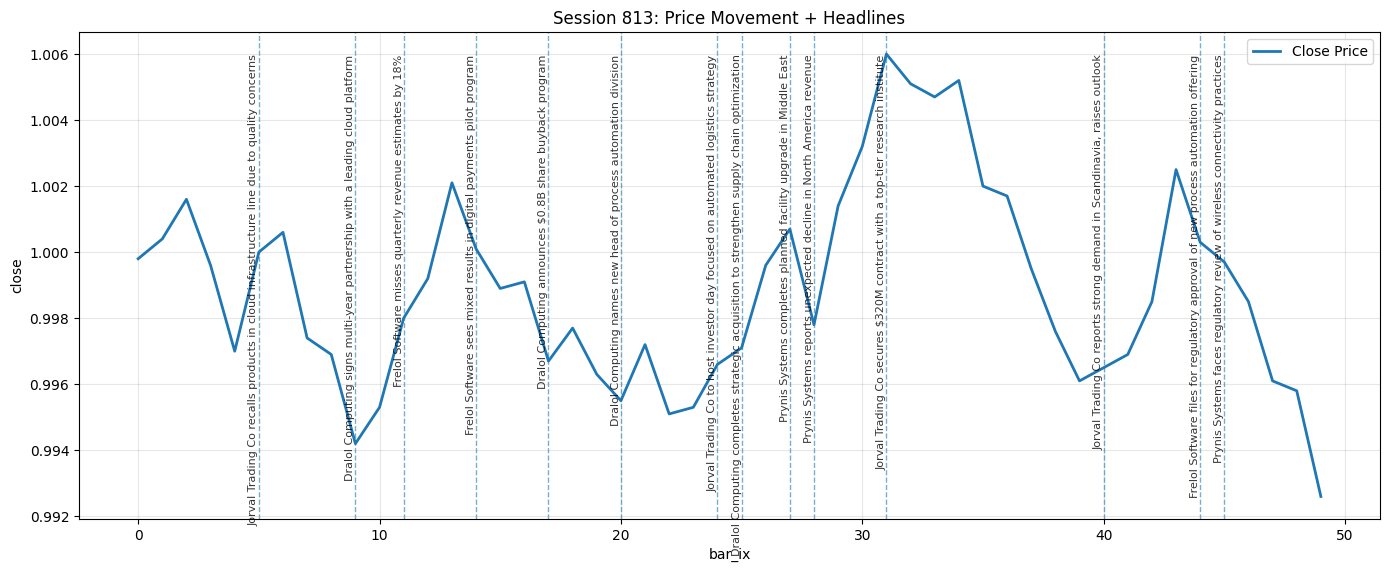

In [146]:
plot_session_with_news(bars_df, headlines_df, session_n=108)
plot_session_with_news(bars_df, headlines_df, session_n=415)
plot_session_with_news(bars_df, headlines_df, session_n=813)

In [148]:
import matplotlib.pyplot as plt
import pandas as pd


def plot_sessions_aligned_by_headline(
    bars_df,
    headlines_df,
    headline_query,
    price_col="close",
    figsize=(14, 6),
):
    """
    Align multiple sessions on a given headline and plot them together.

    Each session is shifted so that the matched headline occurs at x = 0.
    """

    # ---- Find matching headlines ----
    matched_news = headlines_df[
        headlines_df["headline"].str.contains(headline_query, case=False, na=False)
    ].copy()

    if matched_news.empty:
        print(f"No headlines found matching: {headline_query}")
        return

    fig, ax = plt.subplots(figsize=figsize)

    # ---- Plot each session aligned on headline ----
    for _, news_row in matched_news.iterrows():
        session = news_row["session"]
        headline_bar = news_row["bar_ix"]

        bars = bars_df[bars_df["session"] == session].copy()
        if bars.empty:
            continue

        bars = bars.sort_values("bar_ix")

        # Align time so headline is at x = 0
        bars["aligned_x"] = bars["bar_ix"] - headline_bar

        ax.plot(
            bars["aligned_x"],
            bars[price_col],
            lw=1.5,
            alpha=0.7,
            label=f"Session {session}"
        )

        # Mark ONLY the selected headline at x=0
        ax.axvline(0, color="black", linestyle="--", alpha=0.8)

        ax.scatter(
            0,
            bars.loc[bars["bar_ix"] == headline_bar, price_col].values[0],
            color="red",
            zorder=5
        )

    ax.set_title(f"Sessions Aligned on Headline: '{headline_query}'")
    ax.set_xlabel("Bars relative to headline (0 = event)")
    ax.set_ylabel(price_col)
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()

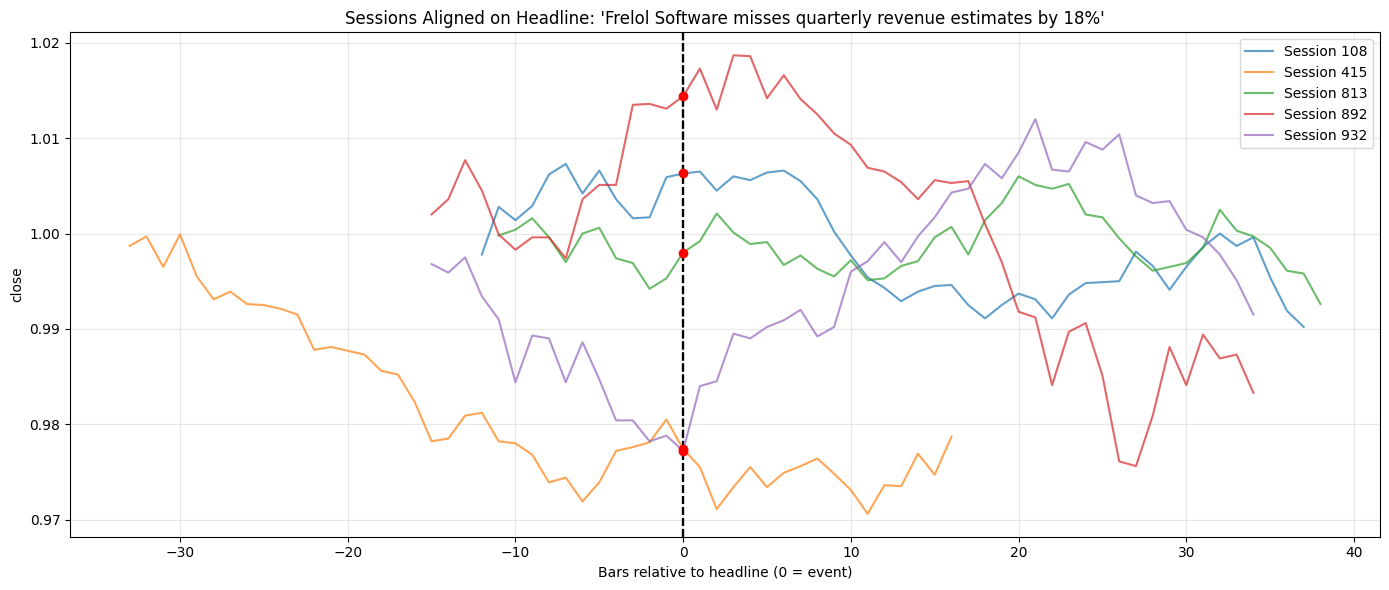

In [149]:
plot_sessions_aligned_by_headline(bars_df, headlines_df, headline_query="Frelol Software misses quarterly revenue estimates by 18%")

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


def plot_sessions_aligned_by_headline(
    bars_df,
    headlines_df,
    headline_query,
    bars_df_extra=None,   # NEW: second dataset (bar_ix > 50)
    price_col="close",
    figsize=(14, 6),
):
    """
    Align multiple sessions on a given headline and plot them together.

    Each session is shifted so that the matched headline occurs at x = 0.
    Optionally overlays extra bars (e.g. bar_ix > 50) in black.
    """

    # ---- Find matching headlines ----
    matched_news = headlines_df[
        headlines_df["headline"].str.contains(headline_query, case=False, na=False)
    ].copy()

    if matched_news.empty:
        print(f"No headlines found matching: {headline_query}")
        return

    fig, ax = plt.subplots(figsize=figsize)

    # ---- Plot each session aligned on headline ----
    for _, news_row in matched_news.iterrows():
        session = news_row["session"]
        headline_bar = news_row["bar_ix"]

        # ---------------- base bars (bar_ix < 50 or full primary set) ----------------
        bars = bars_df[bars_df["session"] == session].copy()
        if bars.empty:
            continue

        bars = bars.sort_values("bar_ix")
        bars["aligned_x"] = bars["bar_ix"] - headline_bar

        ax.plot(
            bars["aligned_x"],
            bars[price_col],
            lw=1.5,
            alpha=0.7,
            label=f"Session {session}"
        )

        # Mark headline
        ax.axvline(0, color="black", linestyle="--", alpha=0.8)

        ax.scatter(
            0,
            bars.loc[bars["bar_ix"] == headline_bar, price_col].values[0],
            color="red",
            zorder=5
        )

        # ---------------- extra bars (bar_ix > 50) ----------------
        extra = extra.sort_values("bar_ix")

        # build continuous x-axis
        x = extra["bar_ix"].values - headline_bar
        y = extra[price_col].values

        ax.plot(x, y, color="black", lw=1.2, alpha=0.9)

    ax.set_title(f"Sessions Aligned on Headline: '{headline_query}'")
    ax.set_xlabel("Bars relative to headline (0 = event)")
    ax.set_ylabel(price_col)
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()

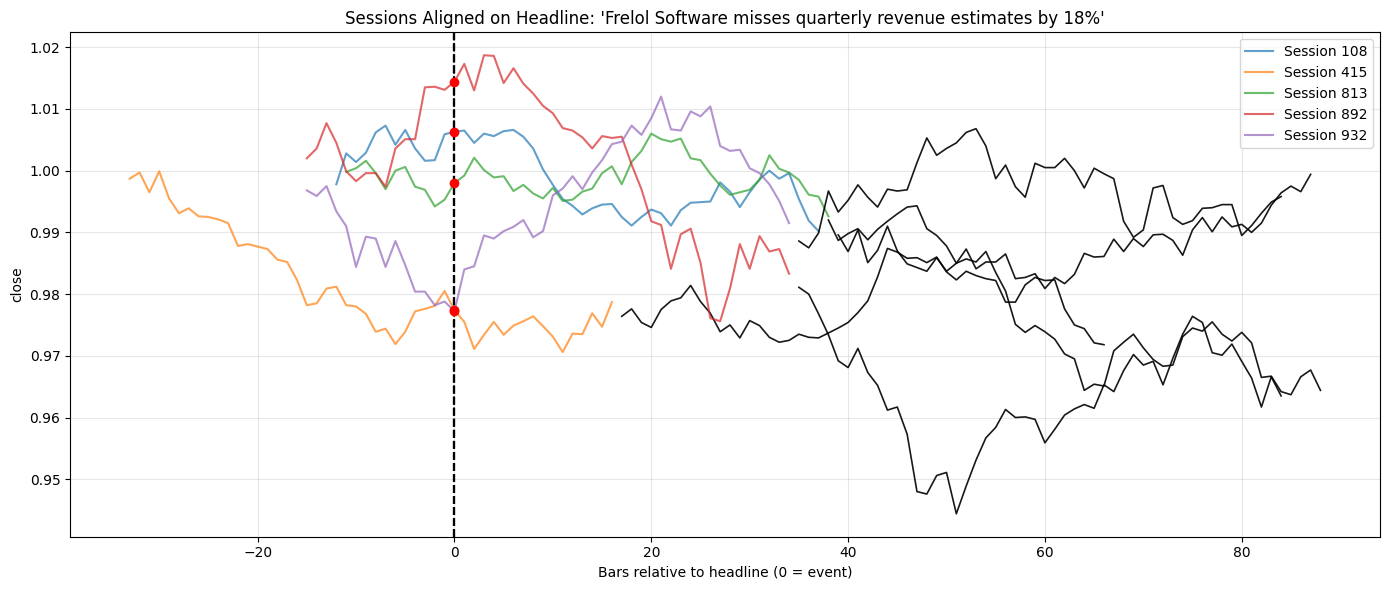

In [153]:
plot_sessions_aligned_by_headline(bars_df, headlines_df, bars_df_extra=bars_unseen_df, headline_query="Frelol Software misses quarterly revenue estimates by 18%")